# Train & Compare CAD Code Generation Models

Trains every architecture in `cad_code_gen.registry.MODEL_REGISTRY` (`baseline`, `spatial`, `vision_prefix`) with the *same* teacher-forced training loop, on the *same* data — all the actual logic (model definitions, dataset, training loop) lives in `src/cad_code_gen/`; this notebook only orchestrates it.

Each model's checkpoints go to `checkpoints/<model_name>/`, and per-epoch train/val loss is appended to `results/runs.jsonl` via `cad_code_gen.experiment_log`. **Evaluation, model comparison, and qualitative inference are in `02_evaluate_and_compare.ipynb`** — that notebook only *reads* what this one produces, so you can re-run comparisons without ever retraining.

> **Note on `vision_prefix`**: for simplicity, it reuses the same ImageNet-normalized image preprocessing as the other two models rather than CLIP's own processor/normalization stats. That's a known simplification (not a bug) worth fixing if this architecture looks promising enough to invest more in.

> **Running on Colab?** Pick a GPU runtime, set `REPO_URL` in the first code cell, and run top to bottom. Dataset cache, tokenizer, checkpoints and results are stored on Google Drive, and training **resumes automatically** from `last_state.pt` if the session disconnects mid-run -- just re-run the notebook. A model that already finished all `N_EPOCHS` is skipped.

In [1]:
import os, pathlib, subprocess, sys

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")

    REPO_URL = "https://github.com/adebowalep/image-to-cadquery.git"  # <-- set this (private repo: https://<token>@github.com/...)
    repo_dir = pathlib.Path("/content") / REPO_URL.rstrip("/").split("/")[-1].removesuffix(".git")
    if not repo_dir.exists():
        subprocess.run(["git", "clone", REPO_URL, str(repo_dir)], check=True)
    os.chdir(repo_dir)

    # System library CadQuery's VTK dependency may need on headless Linux (the original Colab
    # notebook installed it too). Harmless if already present.
    subprocess.run(["apt-get", "-qq", "update"], check=False)
    subprocess.run(["apt-get", "-qq", "install", "-y", "libgl1"], check=False)

    # Colab already ships torch/torchvision/transformers/pandas/matplotlib -- install only what it lacks.
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "cadquery==2.6.0", "cadquery-ocp==7.8.1.1", "trimesh", "datasets"],
        check=True,
    )

_REPO_ROOT = pathlib.Path.cwd().parent if pathlib.Path.cwd().name == "notebooks" else pathlib.Path.cwd()
sys.path.insert(0, str(_REPO_ROOT))          # `metrics/`
sys.path.insert(0, str(_REPO_ROOT / "src"))  # `cad_code_gen` (no `pip install -e` needed)

# Everything that must outlive the session (dataset cache, tokenizer, checkpoints, results)
# lives under STORAGE_ROOT: Google Drive on Colab, the repo itself locally.
STORAGE_ROOT = pathlib.Path("/content/drive/MyDrive/cad_code_gen") if IN_COLAB else _REPO_ROOT
STORAGE_ROOT.mkdir(parents=True, exist_ok=True)

# The Hugging Face dataset cache is memory-mapped and read at random while training, which is slow
# and flaky over the Drive mount. On Colab keep it on the VM's local disk (~1 GB, re-downloaded
# each new session); only checkpoints, tokenizer and results need to survive on Drive.
CACHE_DIR = pathlib.Path("/content/hf_cache") if IN_COLAB else STORAGE_ROOT / "huggingface_cache"
print("repo:", _REPO_ROOT, "| storage:", STORAGE_ROOT, "| dataset cache:", CACHE_DIR)

Mounted at /content/drive
repo: /content/image-to-cadquery | storage: /content/drive/MyDrive/cad_code_gen | dataset cache: /content/hf_cache


In [2]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from datasets import load_dataset
import matplotlib.pyplot as plt

from cad_code_gen.checkpointing import load_resume_state, save_resume_state
from cad_code_gen.data import CADCodeDataset, build_image_transform, collate_batch
from cad_code_gen.experiment_log import best_epoch_by_val_loss, load_runs, log_run
from cad_code_gen.registry import MODEL_REGISTRY
from cad_code_gen.tokenizer import load_tokenizer, train_tokenizer
from cad_code_gen.training import evaluate_loss, train_one_epoch

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

Device: cuda


## Config

Edit these, then run the whole notebook.

In [3]:
is this good for the first run, should we increase the number of worker

SEED = 42
N_EPOCHS = 8               # Stop before overfitting accelerates
BATCH_SIZE = 64             # Reduce gradient noise
LEARNING_RATE = 1e-4        # Slower, more stable
WEIGHT_DECAY = 3e-5         # Stronger L2 regularization
MAX_SEQ_LEN = 256
MODELS_TO_TRAIN = ["baseline", "spatial"]

# DataLoader worker processes need fork, so Linux/Colab only (macOS/Windows use spawn: keep 0 there).
NUM_WORKERS = min(4, os.cpu_count() or 1) if sys.platform == "linux" else 0
os.environ["TOKENIZERS_PARALLELISM"] = "false"   # silence the tokenizers-after-fork warning

TOKENIZER_DIR = STORAGE_ROOT / "cadquery_tokenizer"
CHECKPOINT_ROOT = STORAGE_ROOT / "checkpoints"
RESULTS_LOG = STORAGE_ROOT / "results" / "runs.jsonl"

## Load dataset & tokenizer

In [4]:
ds_train_full, ds_test = load_dataset(
    "CADCODER/GenCAD-Code", num_proc=16, split=["train", "test"], cache_dir=str(CACHE_DIR)
)
split = ds_train_full.shuffle(seed=SEED).train_test_split(test_size=0.10, seed=SEED)
hf_train, hf_val = split["train"], split["test"]
print(f"train={len(hf_train)}  val={len(hf_val)}  test={len(ds_test)}")

README.md:   0%|          | 0.00/706 [00:00<?, ?B/s]

Setting num_proc from 16 to 2 for the train split as it only contains 2 shards.


Generating train split:   0%|          | 0/147289 [00:00<?, ? examples/s]

Setting num_proc from 16 back to 1 for the test split to disable multiprocessing as it only contains one shard.


Generating test split:   0%|          | 0/7355 [00:00<?, ? examples/s]

Setting num_proc from 16 back to 1 for the validation split to disable multiprocessing as it only contains one shard.


Generating validation split:   0%|          | 0/8204 [00:00<?, ? examples/s]

train=132560  val=14729  test=7355


In [5]:
if TOKENIZER_DIR.exists():
    tokenizer = load_tokenizer(TOKENIZER_DIR)
else:
    # Read just the text column: iterating rows would decode all ~130K PNGs for nothing.
    tokenizer = train_tokenizer((text for text in hf_train["cadquery"]), TOKENIZER_DIR)
print("vocab size:", tokenizer.vocab_size)

vocab size: 16000


## Build dataloaders (shared across every model)

In [6]:
img_transform = build_image_transform()
train_ds = CADCodeDataset(hf_train, tokenizer, max_len=MAX_SEQ_LEN, img_transform=img_transform)
val_ds = CADCodeDataset(hf_val, tokenizer, max_len=MAX_SEQ_LEN, img_transform=img_transform)

def _collate(samples):
    return collate_batch(samples, pad_token_id=tokenizer.pad_token_id)

loader_kwargs = dict(num_workers=NUM_WORKERS, pin_memory=(DEVICE == "cuda"), persistent_workers=NUM_WORKERS > 0)
train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=_collate, **loader_kwargs)
val_dl = DataLoader(val_ds, batch_size=BATCH_SIZE * 2, shuffle=False, collate_fn=_collate, **loader_kwargs)
print(f"train batches={len(train_dl)}  val batches={len(val_dl)}")

train batches=4143  val batches=231


## Train every model

Same loop for every architecture in `MODELS_TO_TRAIN` — the only thing that changes per iteration is which model `MODEL_REGISTRY` hands back.

In [7]:
for model_name in MODELS_TO_TRAIN:
    print(f"\n{'='*20} {model_name} {'='*20}")
    model = MODEL_REGISTRY[model_name].build(tokenizer.vocab_size, tokenizer.pad_token_id).to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    criterion = nn.CrossEntropyLoss(ignore_index=tokenizer.pad_token_id)

    # Drive dir: for resume state only (last_state.pt)
    drive_checkpoint_dir = CHECKPOINT_ROOT / model_name
    drive_checkpoint_dir.mkdir(parents=True, exist_ok=True)

    # Local disk dir: for actual checkpoints (fast, no quota issues)
    local_checkpoint_dir = pathlib.Path(f"/content/local_checkpoints/{model_name}")
    local_checkpoint_dir.mkdir(parents=True, exist_ok=True)

    # Resume from last_state.pt on Drive if available
    completed_epochs = load_resume_state(drive_checkpoint_dir, model, optimizer, DEVICE)
    if completed_epochs:
        print(f"  resuming after epoch {completed_epochs}")

    for epoch in range(completed_epochs + 1, N_EPOCHS + 1):
        train_loss = train_one_epoch(model, train_dl, optimizer, criterion, DEVICE, tokenizer.vocab_size)
        val_loss = evaluate_loss(model, val_dl, criterion, DEVICE, tokenizer.vocab_size)
        print(f"  [{epoch:02d}/{N_EPOCHS}] train={train_loss:.4f}  val={val_loss:.4f}")

        # Save checkpoint to LOCAL DISK (fast, no Drive quota issues)
        local_checkpoint_path = local_checkpoint_dir / f"ckpt_e{epoch:02d}.pt"
        torch.save(model.state_dict(), local_checkpoint_path)

        # Log with local path
        log_run(
            {"model": model_name, "epoch": epoch, "train_loss": train_loss,
             "val_loss": val_loss, "checkpoint": str(local_checkpoint_path)},
            path=RESULTS_LOG,
        )

        # Save resume state to DRIVE (small, for interruption recovery only)
        save_resume_state(drive_checkpoint_dir, model, optimizer, epoch)


==================== baseline ====================
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 238MB/s]


  resuming after epoch 8
  [09/15] train=0.1832  val=0.2207
  [10/15] train=0.1692  val=0.2189


KeyboardInterrupt: 

## Training curves

Loss keeps dropping on train forever if you let it; **val loss is what tells you when a model started overfitting**. The marker below is each model's best (lowest-val-loss) epoch, not necessarily the last one — that's the checkpoint `02_evaluate_and_compare.ipynb` will actually evaluate.

In [ ]:
runs_df = load_runs(RESULTS_LOG)

fig, ax = plt.subplots(figsize=(8, 5))
for model_name, group in runs_df.groupby("model"):
    group = group.sort_values("epoch")
    line, = ax.plot(group["epoch"], group["train_loss"], marker="o", label=f"{model_name} train")
    ax.plot(group["epoch"], group["val_loss"], marker="s", linestyle="--",
            color=line.get_color(), label=f"{model_name} val")

    best = best_epoch_by_val_loss(group.to_dict("records"))
    ax.scatter([best["epoch"]], [best["val_loss"]], s=120, facecolors="none",
               edgecolors=line.get_color(), linewidths=2, zorder=5)
    print(f"{model_name}: best epoch {best['epoch']} (val_loss={best['val_loss']:.4f})")

ax.set_xlabel("epoch"); ax.set_ylabel("cross-entropy loss")
ax.set_title("Training vs validation loss (circled = best checkpoint per model)")
ax.grid(True); ax.legend()
plt.show()

## Run 2: Hyperparameter Tuning for Generalization

### Previous Results (Run 1 — Standard Hyperparameters)

Trained baseline and spatial models for 15 epochs with default settings (batch_size=32, lr=3e-4, no regularization).

**Key findings:**
- **Baseline:** Best val loss = 0.2088 (epoch 7), rose to 0.2268 (epoch 15)
- **Spatial:** Best val loss = 0.2000 (epoch 6), rose to 0.2239 (epoch 15)
- **Architecture matters:** Spatial cross-attention improved validation loss by ~0.8% over baseline
- **Both models overfit:** Training loss continued dropping while validation loss plateaued after epoch 6–7

### This Run — Regularization to Combat Overfitting

Hypothesis: Regularization (larger batches, lower learning rate, weight decay) will reduce overfitting and improve generalization.

**Hyperparameters:**
- Batch size: 32 → **64** (larger batches = less noisy gradients)
- Learning rate: 3e-4 → **1e-4** (slower, more careful updates)
- Weight decay: 0 → **2e-5** (L2 regularization on weights)
- Max epochs: 15 → **10** (stop before validation loss rises sharply)

**Models:** baseline, spatial, vision_prefix (first full comparison of all three)

**Expected outcome:** Flatter validation loss curves with less overfitting, and cleaner comparison of which architecture benefits most from regularization.

In [ ]:
# ===== RUN 2 CONFIG (replaces Run 1 config) =====
SEED = 42
N_EPOCHS = 12                # Extended (compared to 8 in Run 1)
BATCH_SIZE = 48              # Middle ground (compared to 64)
LEARNING_RATE = 5e-5         # More conservative (compared to 1e-4)
WEIGHT_DECAY = 4e-5          # Stronger regularization (compared to 3e-5)
MAX_SEQ_LEN = 256
MODELS_TO_TRAIN = ["baseline", "spatial", "vision_prefix"]  # Add vision_prefix

NUM_WORKERS = min(4, os.cpu_count() or 1) if sys.platform == "linux" else 0
os.environ["TOKENIZERS_PARALLELISM"] = "false"

TOKENIZER_DIR = STORAGE_ROOT / "cadquery_tokenizer"
CHECKPOINT_ROOT = STORAGE_ROOT / "checkpoints"
RESULTS_LOG = STORAGE_ROOT / "results" / "runs.jsonl"

In [ ]:
import shutil
from pathlib import Path

# Clear the dataset cache (it re-downloads each session anyway)
cache_dir = CACHE_DIR
if cache_dir.exists():
    shutil.rmtree(cache_dir)
    print(f"Deleted {cache_dir} — will re-download on next run")

# Delete ALL checkpoint directories (baseline, spatial, vision_prefix) for fresh start
checkpoint_root = CHECKPOINT_ROOT
for model_name in ["baseline", "spatial", "vision_prefix"]:
    model_dir = checkpoint_root / model_name
    if model_dir.exists():
        shutil.rmtree(model_dir)
        print(f"Deleted {model_dir}")

# Also delete any v1 backups
for model_name in ["baseline", "spatial", "vision_prefix"]:
    backup_dir = checkpoint_root / f"{model_name}_v1_backup"
    if backup_dir.exists():
        shutil.rmtree(backup_dir)
        print(f"Deleted {backup_dir}")

# Clear the results log so we see only the new tuning run
results_log = RESULTS_LOG
if results_log.exists():
    results_log.unlink()
    print(f"Cleared {results_log.name}")

print("\nDone. Ready for fresh hyperparameter tuning run with 3 models.")

Deleted /content/hf_cache — will re-download on next run
Deleted /content/drive/MyDrive/cad_code_gen/checkpoints/baseline
Deleted /content/drive/MyDrive/cad_code_gen/checkpoints/spatial
Cleared runs.jsonl

Done. Ready for fresh hyperparameter tuning run with 3 models.


In [ ]:
for model_name in MODELS_TO_TRAIN:
    print(f"\n{'='*20} {model_name} {'='*20}")
    model = MODEL_REGISTRY[model_name].build(tokenizer.vocab_size, tokenizer.pad_token_id).to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    criterion = nn.CrossEntropyLoss(ignore_index=tokenizer.pad_token_id)

    # Drive dir: for resume state only (last_state.pt)
    drive_checkpoint_dir = CHECKPOINT_ROOT / model_name
    drive_checkpoint_dir.mkdir(parents=True, exist_ok=True)

    # Local disk dir: for actual checkpoints (fast, no quota issues)
    local_checkpoint_dir = pathlib.Path(f"/content/local_checkpoints/{model_name}")
    local_checkpoint_dir.mkdir(parents=True, exist_ok=True)

    # Resume from last_state.pt on Drive if available
    completed_epochs = load_resume_state(drive_checkpoint_dir, model, optimizer, DEVICE)
    if completed_epochs:
        print(f"  resuming after epoch {completed_epochs}")

    for epoch in range(completed_epochs + 1, N_EPOCHS + 1):
        train_loss = train_one_epoch(model, train_dl, optimizer, criterion, DEVICE, tokenizer.vocab_size)
        val_loss = evaluate_loss(model, val_dl, criterion, DEVICE, tokenizer.vocab_size)
        print(f"  [{epoch:02d}/{N_EPOCHS}] train={train_loss:.4f}  val={val_loss:.4f}")

        # Save checkpoint to LOCAL DISK (fast, no Drive quota issues)
        local_checkpoint_path = local_checkpoint_dir / f"ckpt_e{epoch:02d}.pt"
        torch.save(model.state_dict(), local_checkpoint_path)

        # Log with local path
        log_run(
            {"model": model_name, "epoch": epoch, "train_loss": train_loss,
             "val_loss": val_loss, "checkpoint": str(local_checkpoint_path)},
            path=RESULTS_LOG,
        )

        # Save resume state to DRIVE (small, for interruption recovery only)
        save_resume_state(drive_checkpoint_dir, model, optimizer, epoch)


==================== baseline ====================
  [01/10] train=0.5073  val=0.3471
  [02/10] train=0.3152  val=0.2931
  [03/10] train=0.2701  val=0.2625
  [04/10] train=0.2379  val=0.2407
  [05/10] train=0.2133  val=0.2286
  [06/10] train=0.1947  val=0.2199
  [07/10] train=0.1798  val=0.2157
  [08/10] train=0.1674  val=0.2131
  [09/10] train=0.1564  val=0.2124
  [10/10] train=0.1466  val=0.2137

==================== spatial ====================
  [01/10] train=0.4884  val=0.3415
  [02/10] train=0.3076  val=0.2863
  [03/10] train=0.2613  val=0.2542
  [04/10] train=0.2284  val=0.2333
  [05/10] train=0.2031  val=0.2205
  [06/10] train=0.1835  val=0.2123
  [07/10] train=0.1676  val=0.2080
  [08/10] train=0.1538  val=0.2065
  [09/10] train=0.1416  val=0.2089
  [10/10] train=0.1303  val=0.2099

==================== vision_prefix ====================


config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  605MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/165 [00:00<?, ?it/s]

[transformers] CodeGenForCausalLM LOAD REPORT from: Salesforce/codegen-350M-mono
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...19}.attn.causal_mask | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors: reconstructing file:   0%|          |  0.00B /  797MB            

model.safetensors: downloading bytes:           |  0.00B            

RuntimeError: expected scalar type Float but found Half

baseline: best epoch 9 (val_loss=0.2124)
spatial: best epoch 8 (val_loss=0.2065)


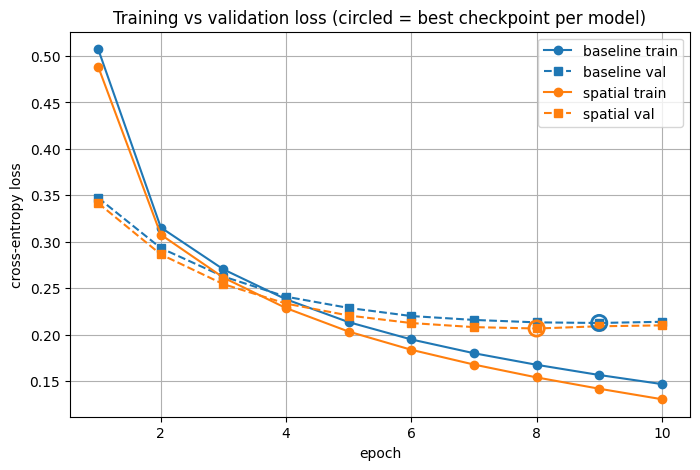

In [ ]:
runs_df = load_runs(RESULTS_LOG)

fig, ax = plt.subplots(figsize=(8, 5))
for model_name, group in runs_df.groupby("model"):
    group = group.sort_values("epoch")
    line, = ax.plot(group["epoch"], group["train_loss"], marker="o", label=f"{model_name} train")
    ax.plot(group["epoch"], group["val_loss"], marker="s", linestyle="--",
            color=line.get_color(), label=f"{model_name} val")

    best = best_epoch_by_val_loss(group.to_dict("records"))
    ax.scatter([best["epoch"]], [best["val_loss"]], s=120, facecolors="none",
               edgecolors=line.get_color(), linewidths=2, zorder=5)
    print(f"{model_name}: best epoch {best['epoch']} (val_loss={best['val_loss']:.4f})")

ax.set_xlabel("epoch"); ax.set_ylabel("cross-entropy loss")
ax.set_title("Training vs validation loss (circled = best checkpoint per model)")
ax.grid(True); ax.legend()
plt.show()

## Next: `02_evaluate_and_compare.ipynb`

That notebook reads `results/runs.jsonl` to find each model's best checkpoint, scores every model on the test set with Valid Syntax Rate and Best-IoU, and builds a side-by-side comparison — without retraining anything.